In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append(f"./../")
from src.misc import *

## Same Target Qubit

### Fully Disjoint Control Patterns

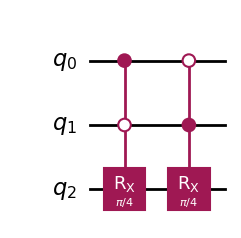

In [2]:
theta = np.pi / 4
qc = QuantumCircuit(3)
rx1 = multi_crx(theta, '10')
rx2 = multi_crx(theta, '01')
qc.append(rx1, [0,1,2])
qc.append(rx2, [0,1,2])
qc.draw('mpl')

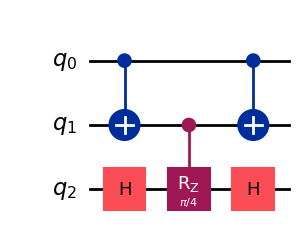

In [3]:
qc_simplified = QuantumCircuit(3)
qc_simplified.h(2)
qc_simplified.cx(0, 1)
qc_simplified.crz(theta, 1, 2)
qc_simplified.cx(0, 1)
qc_simplified.h(2)
qc_simplified.draw('mpl')

In [4]:
state1 = get_state(qc)
state2 = get_state(qc_simplified)

results = compare_quantum_states(state1, state2, tolerance=1e-10, verbose=False)

detailed_state_analysis(state1, state2)

_ = analyze_circuit_comparison(qc, qc_simplified)

Detailed State Analysis:
Fidelity: 1.0000000000
Number of qubits: 3
Non-zero amplitudes (tolerance=1e-10):
State Amplitude 1     Amplitude 2     Difference   Match
-----------------------------------------------------
|000⟩ 0.353553-0.000000j 0.353553+0.000000j    1.67e-16     ✓
|001⟩ 0.326641-0.135299j 0.326641-0.135299j    2.48e-16     ✓
|010⟩ 0.326641-0.135299j 0.326641-0.135299j    2.29e-16     ✓
|011⟩ 0.353553+0.000000j 0.353553+0.000000j    1.67e-16     ✓
|100⟩ 0.353553+0.000000j 0.353553+0.000000j    1.67e-16     ✓
|101⟩ 0.326641-0.135299j 0.326641-0.135299j    3.34e-16     ✓
|110⟩ 0.326641-0.135299j 0.326641-0.135299j    2.24e-16     ✓
|111⟩ 0.353553+0.000000j 0.353553+0.000000j    1.67e-16     ✓
Circuit Comparison Analysis:
Original circuit - CX: 16, U3: 17
Simplified circuit - CX: 4, U3: 3
CX gate reduction: 12 (75.00%)
U3 gate reduction: 14 (82.35%)



### Partially Overlapping Control Patterns

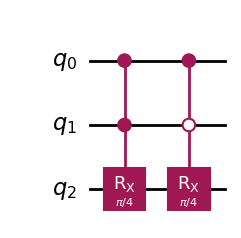

In [5]:
theta = np.pi / 4
qc = QuantumCircuit(3)
rx1 = multi_crx(theta, '11')
rx2 = multi_crx(theta, '10')
qc.append(rx1, [0,1,2])
qc.append(rx2, [0,1,2])
qc.draw('mpl')

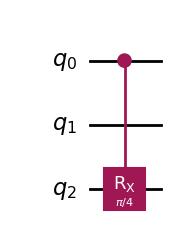

In [6]:
qc_simplified = QuantumCircuit(3)
qc_simplified.crx(theta, 0, 2)
qc_simplified.draw('mpl')

In [7]:
state1 = get_state(qc)
state2 = get_state(qc_simplified)

results = compare_quantum_states(state1, state2, tolerance=1e-10, verbose=False)

detailed_state_analysis(state1, state2)

_ = analyze_circuit_comparison(qc, qc_simplified)

Detailed State Analysis:
Fidelity: 1.0000000000
Number of qubits: 3
Non-zero amplitudes (tolerance=1e-10):
State Amplitude 1     Amplitude 2     Difference   Match
-----------------------------------------------------
|000⟩ 0.353553+0.000000j 0.353553+0.000000j    5.60e-17     ✓
|001⟩ 0.326641-0.135299j 0.326641-0.135299j    2.24e-16     ✓
|010⟩ 0.353553+0.000000j 0.353553+0.000000j    5.60e-17     ✓
|011⟩ 0.326641-0.135299j 0.326641-0.135299j    2.83e-16     ✓
|100⟩ 0.353553+0.000000j 0.353553+0.000000j    5.73e-17     ✓
|101⟩ 0.326641-0.135299j 0.326641-0.135299j    2.29e-16     ✓
|110⟩ 0.353553+0.000000j 0.353553+0.000000j    5.73e-17     ✓
|111⟩ 0.326641-0.135299j 0.326641-0.135299j    2.79e-16     ✓
Circuit Comparison Analysis:
Original circuit - CX: 16, U3: 15
Simplified circuit - CX: 2, U3: 3
CX gate reduction: 14 (87.50%)
U3 gate reduction: 12 (80.00%)



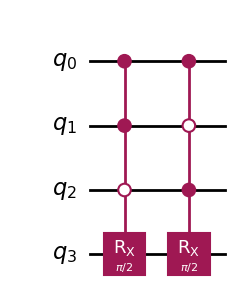

In [8]:
theta = 2*np.pi / 4
qc = QuantumCircuit(4)
rx1 = multi_crx(theta, '110')
rx2 = multi_crx(theta, '101')
qc.append(rx1, [0,1,2,3])
qc.append(rx2, [0,1,2,3])
qc.draw('mpl')

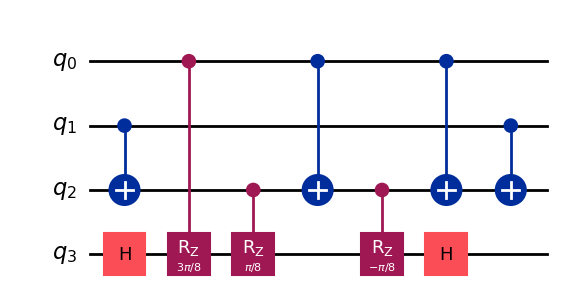

In [9]:
qc_simplified = QuantumCircuit(4)
qc_simplified.h(3)
qc_simplified.crz(theta/2 + theta/4, 0, 3)
qc_simplified.cx(1,2)
# qc_simplified.crz(theta/4, 0, 3)
qc_simplified.crz(theta/4, 2, 3)
qc_simplified.cx(0,2)
qc_simplified.crz(-theta/4, 2, 3)
qc_simplified.cx(0,2)
qc_simplified.cx(1,2)
qc_simplified.h(3)
qc_simplified.draw('mpl')

In [10]:
state1 = get_state(qc)
state2 = get_state(qc_simplified)

results = compare_quantum_states(state1, state2, tolerance=1e-10, verbose=False)

detailed_state_analysis(state1, state2)

_ = analyze_circuit_comparison(qc, qc_simplified)

Detailed State Analysis:
Fidelity: 0.9714548247
Number of qubits: 4
Non-zero amplitudes (tolerance=1e-10):
State  Amplitude 1     Amplitude 2     Difference   Match
------------------------------------------------------
|0000⟩ 0.250000-0.000000j 0.250000+0.000000j    3.33e-16     ✓
|0001⟩ 0.250000-0.000000j 0.230970-0.095671j    9.75e-02     ✗
|0010⟩ 0.250000-0.000000j 0.250000-0.000000j    2.22e-16     ✓
|0011⟩ 0.176777-0.176777j 0.176777-0.176777j    3.48e-16     ✓
|0100⟩ 0.250000-0.000000j 0.250000-0.000000j    2.78e-16     ✓
|0101⟩ 0.176777-0.176777j 0.176777-0.176777j    4.34e-16     ✓
|0110⟩ 0.250000-0.000000j 0.250000+0.000000j    3.89e-16     ✓
|0111⟩ 0.250000+0.000000j 0.230970-0.095671j    9.75e-02     ✗
|1000⟩ 0.250000+0.000000j 0.250000+0.000000j    2.78e-16     ✓
|1001⟩ 0.250000+0.000000j 0.230970-0.095671j    9.75e-02     ✗
|1010⟩ 0.250000+0.000000j 0.250000-0.000000j    2.23e-16     ✓
|1011⟩ 0.176777-0.176777j 0.176777-0.176777j    4.32e-16     ✓
|1100⟩ 0.250000+0.000000

this circuit does not simplfy further

### Subset Control Patterns

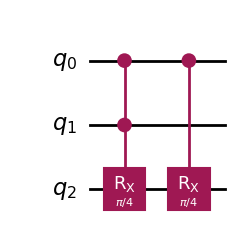

In [11]:
theta = np.pi / 4
qc = QuantumCircuit(3)
rx1 = multi_crx(theta, '11')
qc.append(rx1, [0,1,2])
qc.crx(theta, 0, 2)
qc.draw('mpl')

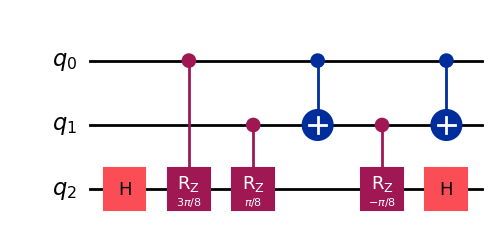

In [12]:
qc_simplified = QuantumCircuit(3)
qc_simplified.h(2)
qc_simplified.crz(theta + theta/2, 0, 2)
# qc_simplified.crz(theta/2, 0, 2)
qc_simplified.crz(theta/2, 1, 2)
qc_simplified.cx(0, 1)
qc_simplified.crz(-theta/2, 1, 2)
qc_simplified.cx(0, 1)
qc_simplified.h(2)
qc_simplified.draw('mpl')

In [13]:
state1 = get_state(qc)
state2 = get_state(qc_simplified)

results = compare_quantum_states(state1, state2, tolerance=1e-10, verbose=False)

detailed_state_analysis(state1, state2)

_ = analyze_circuit_comparison(qc, qc_simplified)

Detailed State Analysis:
Fidelity: 1.0000000000
Number of qubits: 3
Non-zero amplitudes (tolerance=1e-10):
State Amplitude 1     Amplitude 2     Difference   Match
-----------------------------------------------------
|000⟩ 0.353553-0.000000j 0.353553+0.000000j    5.55e-17     ✓
|001⟩ 0.326641-0.135299j 0.326641-0.135299j    1.24e-16     ✓
|010⟩ 0.353553+0.000000j 0.353553+0.000000j    1.11e-16     ✓
|011⟩ 0.250000-0.250000j 0.250000-0.250000j    1.78e-16     ✓
|100⟩ 0.353553+0.000000j 0.353553+0.000000j    5.55e-17     ✓
|101⟩ 0.326641-0.135299j 0.326641-0.135299j    1.24e-16     ✓
|110⟩ 0.353553+0.000000j 0.353553+0.000000j    1.12e-16     ✓
|111⟩ 0.250000-0.250000j 0.250000-0.250000j    1.78e-16     ✓
Circuit Comparison Analysis:
Original circuit - CX: 8, U3: 10
Simplified circuit - CX: 8, U3: 7
CX gate reduction: 0 (0.00%)
U3 gate reduction: 3 (30.00%)



no simplification happens

### Identical Control Patterns

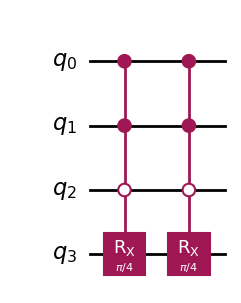

In [14]:
theta = np.pi / 4
qc = QuantumCircuit(4)
rx1 = multi_crx(theta, '110')
rx2 = multi_crx(theta, '110')
qc.append(rx1, [0,1,2,3])
qc.append(rx2, [0,1,2,3])
qc.draw('mpl')

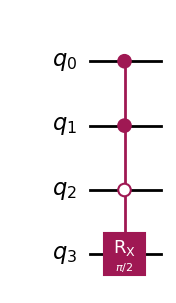

In [15]:
qc_simplified = QuantumCircuit(4)
rx1 = multi_crx(2*theta, '110')
qc_simplified.append(rx1, [0,1,2,3])
qc_simplified.draw('mpl')

In [16]:
state1 = get_state(qc)
state2 = get_state(qc_simplified)

results = compare_quantum_states(state1, state2, tolerance=1e-10, verbose=False)

detailed_state_analysis(state1, state2)

_ = analyze_circuit_comparison(qc, qc_simplified)

Detailed State Analysis:
Fidelity: 1.0000000000
Number of qubits: 4
Non-zero amplitudes (tolerance=1e-10):
State  Amplitude 1     Amplitude 2     Difference   Match
------------------------------------------------------
|0000⟩ 0.250000-0.000000j 0.250000+0.000000j    1.39e-16     ✓
|0001⟩ 0.250000-0.000000j 0.250000+0.000000j    8.39e-17     ✓
|0010⟩ 0.250000+0.000000j 0.250000-0.000000j    8.50e-17     ✓
|0011⟩ 0.176777-0.176777j 0.176777-0.176777j    1.00e-16     ✓
|0100⟩ 0.250000+0.000000j 0.250000+0.000000j    8.33e-17     ✓
|0101⟩ 0.250000+0.000000j 0.250000-0.000000j    1.94e-16     ✓
|0110⟩ 0.250000+0.000000j 0.250000-0.000000j    1.95e-16     ✓
|0111⟩ 0.250000+0.000000j 0.250000-0.000000j    1.39e-16     ✓
|1000⟩ 0.250000+0.000000j 0.250000+0.000000j    3.80e-18     ✓
|1001⟩ 0.250000+0.000000j 0.250000+0.000000j    5.55e-17     ✓
|1010⟩ 0.250000-0.000000j 0.250000+0.000000j    1.25e-17     ✓
|1011⟩ 0.176777-0.176777j 0.176777-0.176777j    2.78e-17     ✓
|1100⟩ 0.250000-0.000000

## Different Target Qubit

###  Complementary Control Patterns

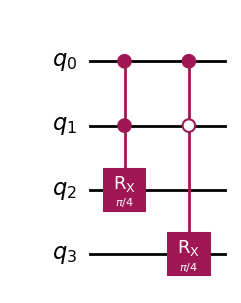

In [17]:
theta = np.pi / 4
qc = QuantumCircuit(4)
rx1 = multi_crx(theta, '11')
rx2 = multi_crx(theta, '10')
qc.append(rx1, [0,1,2])
qc.append(rx2, [0,1,3])
qc.draw('mpl')

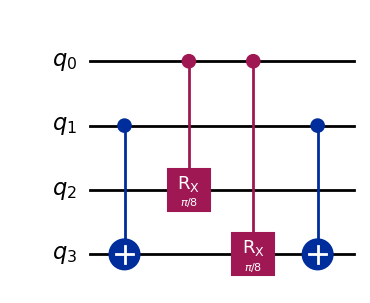

In [18]:
qc_simplified = QuantumCircuit(4)
qc_simplified.cx(1, 3)
qc_simplified.crx(theta/2, 0, 2)
qc_simplified.crx(theta/2, 0, 3)
qc_simplified.cx(1, 3)
qc_simplified.draw('mpl')

In [19]:
state1 = get_state(qc)
state2 = get_state(qc_simplified)

results = compare_quantum_states(state1, state2, tolerance=1e-10, verbose=False)

detailed_state_analysis(state1, state2)

_ = analyze_circuit_comparison(qc, qc_simplified)

Detailed State Analysis:
Fidelity: 1.0000000000
Number of qubits: 4
Non-zero amplitudes (tolerance=1e-10):
State  Amplitude 1     Amplitude 2     Difference   Match
------------------------------------------------------
|0000⟩ 0.250000+0.000000j 0.250000+0.000000j    1.39e-16     ✓
|0001⟩ 0.230970-0.095671j 0.230970-0.095671j    1.39e-16     ✓
|0010⟩ 0.250000+0.000000j 0.250000+0.000000j    8.33e-17     ✓
|0011⟩ 0.230970-0.095671j 0.230970-0.095671j    1.55e-16     ✓
|0100⟩ 0.250000+0.000000j 0.250000+0.000000j    1.39e-16     ✓
|0101⟩ 0.230970-0.095671j 0.230970-0.095671j    1.55e-16     ✓
|0110⟩ 0.250000+0.000000j 0.250000+0.000000j    8.35e-17     ✓
|0111⟩ 0.230970-0.095671j 0.230970-0.095671j    1.55e-16     ✓
|1000⟩ 0.250000+0.000000j 0.250000+0.000000j    1.39e-16     ✓
|1001⟩ 0.230970-0.095671j 0.230970-0.095671j    1.55e-16     ✓
|1010⟩ 0.250000+0.000000j 0.250000+0.000000j    8.33e-17     ✓
|1011⟩ 0.230970-0.095671j 0.230970-0.095671j    1.19e-16     ✓
|1100⟩ 0.250000+0.000000

### Orthogonal Control Patterns

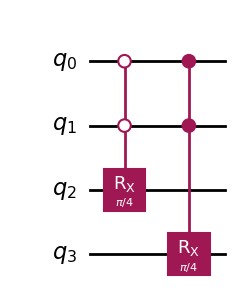

In [20]:
theta = np.pi / 4
qc = QuantumCircuit(4)
rx1 = multi_crx(theta, '00')
rx2 = multi_crx(theta, '11')
qc.append(rx1, [0,1,2])
qc.append(rx2, [0,1,3])
qc.draw('mpl')

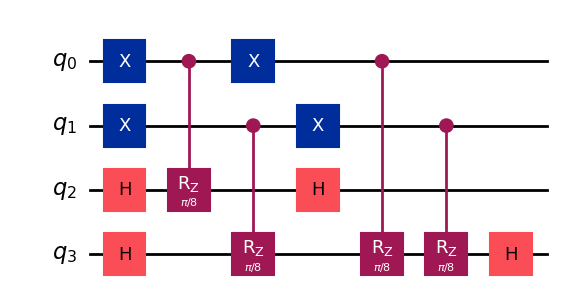

In [21]:
qc_simplified = QuantumCircuit(4)
qc_simplified.x(0)
qc_simplified.x(1)
qc_simplified.h(2)
qc_simplified.h(3)

qc_simplified.crz(theta/2, 0, 2)
qc_simplified.crz(theta/2, 1, 3)

qc_simplified.x(0)
qc_simplified.x(1)

qc_simplified.crz(theta/2, 0, 3)
qc_simplified.crz(theta/2, 1, 3)

qc_simplified.h(2)
qc_simplified.h(3)
qc_simplified.draw('mpl')

In [22]:
state1 = get_state(qc)
state2 = get_state(qc_simplified)

results = compare_quantum_states(state1, state2, tolerance=1e-10, verbose=False)

detailed_state_analysis(state1, state2)

_ = analyze_circuit_comparison(qc, qc_simplified)

Detailed State Analysis:
Fidelity: 0.9619397663
Number of qubits: 4
Non-zero amplitudes (tolerance=1e-10):
State  Amplitude 1     Amplitude 2     Difference   Match
------------------------------------------------------
|0000⟩ 0.230970-0.095671j 0.230970-0.095671j    2.42e-16     ✓
|0001⟩ 0.250000+0.000000j 0.230970-0.095671j    9.75e-02     ✗
|0010⟩ 0.250000-0.000000j 0.230970-0.095671j    9.75e-02     ✗
|0011⟩ 0.230970-0.095671j 0.230970-0.095671j    2.42e-16     ✓
|0100⟩ 0.230970-0.095671j 0.230970-0.095671j    2.42e-16     ✓
|0101⟩ 0.250000+0.000000j 0.230970-0.095671j    9.75e-02     ✗
|0110⟩ 0.250000+0.000000j 0.230970-0.095671j    9.75e-02     ✗
|0111⟩ 0.230970-0.095671j 0.230970-0.095671j    2.42e-16     ✓
|1000⟩ 0.230970-0.095671j 0.230970-0.095671j    2.37e-16     ✓
|1001⟩ 0.250000-0.000000j 0.230970-0.095671j    9.75e-02     ✗
|1010⟩ 0.250000-0.000000j 0.230970-0.095671j    9.75e-02     ✗
|1011⟩ 0.230970-0.095671j 0.230970-0.095671j    2.37e-16     ✓
|1100⟩ 0.230970-0.095671

### Overlapping Control Patterns

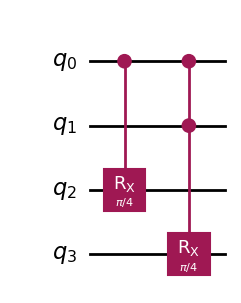

In [23]:
theta = np.pi / 4
qc = QuantumCircuit(4)
rx2 = multi_crx(theta, '11')
qc.crx(theta, 0, 2)
qc.append(rx2, [0,1,3])
qc.draw('mpl')

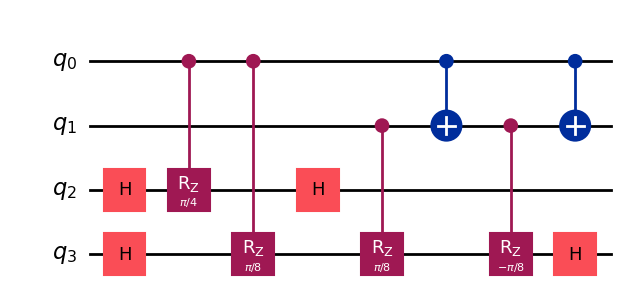

In [24]:
qc_simplified = QuantumCircuit(4)

qc_simplified.h(2)
qc_simplified.h(3)

qc_simplified.crz(theta, 0, 2)
qc_simplified.crz(theta/2, 0, 3)
qc_simplified.crz(theta/2, 1, 3)

qc_simplified.cx(0, 1)

qc_simplified.crz(-theta/2, 1, 3)
qc_simplified.cx(0, 1)

qc_simplified.h(2)
qc_simplified.h(3)
qc_simplified.draw('mpl')

In [25]:
state1 = get_state(qc)
state2 = get_state(qc_simplified)

results = compare_quantum_states(state1, state2, tolerance=1e-10, verbose=False)

detailed_state_analysis(state1, state2)

_ = analyze_circuit_comparison(qc, qc_simplified)

Detailed State Analysis:
Fidelity: 1.0000000000
Number of qubits: 4
Non-zero amplitudes (tolerance=1e-10):
State  Amplitude 1     Amplitude 2     Difference   Match
------------------------------------------------------
|0000⟩ 0.250000+0.000000j 0.250000+0.000000j    1.67e-16     ✓
|0001⟩ 0.230970-0.095671j 0.230970-0.095671j    1.62e-16     ✓
|0010⟩ 0.250000+0.000000j 0.250000+0.000000j    1.67e-16     ✓
|0011⟩ 0.176777-0.176777j 0.176777-0.176777j    1.24e-16     ✓
|0100⟩ 0.250000+0.000000j 0.250000+0.000000j    1.67e-16     ✓
|0101⟩ 0.230970-0.095671j 0.230970-0.095671j    1.62e-16     ✓
|0110⟩ 0.250000+0.000000j 0.250000-0.000000j    1.67e-16     ✓
|0111⟩ 0.176777-0.176777j 0.176777-0.176777j    1.24e-16     ✓
|1000⟩ 0.250000+0.000000j 0.250000+0.000000j    1.67e-16     ✓
|1001⟩ 0.230970-0.095671j 0.230970-0.095671j    1.31e-16     ✓
|1010⟩ 0.250000+0.000000j 0.250000+0.000000j    1.67e-16     ✓
|1011⟩ 0.176777-0.176777j 0.176777-0.176777j    1.78e-16     ✓
|1100⟩ 0.250000+0.000000

### Identical Multi-Control Patterns

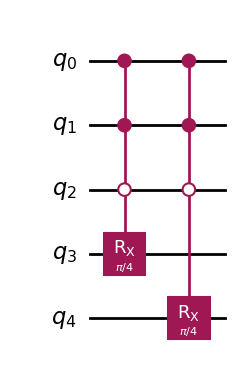

In [26]:
theta = np.pi / 4
qc = QuantumCircuit(5)
rx1 = multi_crx(theta, '110')
rx2 = multi_crx(theta, '110')
qc.append(rx1, [0,1,2,3])
qc.append(rx2, [0,1,2,4])
qc.draw('mpl')

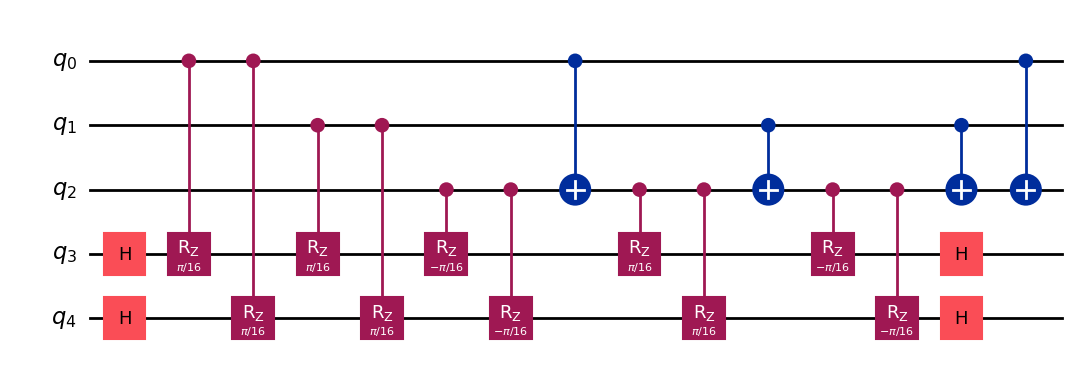

In [27]:
qc_simplified = QuantumCircuit(5)

qc_simplified.h(3)
qc_simplified.h(4)

qc_simplified.crz(theta/4, 0, 3)
qc_simplified.crz(theta/4, 0, 4)

qc_simplified.crz(theta/4, 1, 3)
qc_simplified.crz(theta/4, 1, 4)

qc_simplified.crz(-theta/4, 2, 3)
qc_simplified.crz(-theta/4, 2, 4)

qc_simplified.cx(0, 2)

qc_simplified.crz(theta/4, 2, 3)
qc_simplified.crz(theta/4, 2, 4)

qc_simplified.cx(1, 2)

qc_simplified.crz(-theta/4, 2, 3)
qc_simplified.crz(-theta/4, 2, 4)

qc_simplified.cx(1, 2)
qc_simplified.cx(0, 2)

qc_simplified.h(3)
qc_simplified.h(4)
qc_simplified.draw('mpl')

In [28]:
state1 = get_state(qc)
state2 = get_state(qc_simplified)

results = compare_quantum_states(state1, state2, tolerance=1e-10, verbose=False)

detailed_state_analysis(state1, state2)

_ = analyze_circuit_comparison(qc, qc_simplified)

Detailed State Analysis:
Fidelity: 0.9808775818
Number of qubits: 5
Non-zero amplitudes (tolerance=1e-10):
State   Amplitude 1     Amplitude 2     Difference   Match
-------------------------------------------------------
|00000⟩ 0.176777-0.000000j 0.176777+0.000000j    3.33e-16     ✓
|00001⟩ 0.176777+0.000000j 0.173380-0.034487j    3.47e-02     ✗
|00010⟩ 0.176777+0.000000j 0.176777-0.000000j    1.95e-16     ✓
|00011⟩ 0.125000-0.125000j 0.146984-0.098212j    3.47e-02     ✗
|00100⟩ 0.176777+0.000000j 0.173380+0.034487j    3.47e-02     ✗
|00101⟩ 0.176777+0.000000j 0.176777-0.000000j    3.05e-16     ✓
|00110⟩ 0.176777+0.000000j 0.173380-0.034487j    3.47e-02     ✗
|00111⟩ 0.176777+0.000000j 0.176777-0.000000j    2.78e-16     ✓
|01000⟩ 0.176777+0.000000j 0.176777+0.000000j    1.94e-16     ✓
|01001⟩ 0.176777-0.000000j 0.173380-0.034487j    3.47e-02     ✗
|01010⟩ 0.176777+0.000000j 0.176777-0.000000j    1.67e-16     ✓
|01011⟩ 0.125000-0.125000j 0.146984-0.098212j    3.47e-02     ✗
|01100⟩ 0.